# This jupyter notebook is for week 1 intial coding content and it is also used as a testing ground for exploring new data and learning about new data and techniques 

## Loading in python packages 

In [1]:
import pandas as pd 
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import os
import re
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

### Path for data and basic code for air temperature in San Diego 

5-min rows: 9090  ->  hourly points: 697
Min/Mean/Max hourly temp (F): 56.6 / 64.6 / 76.6


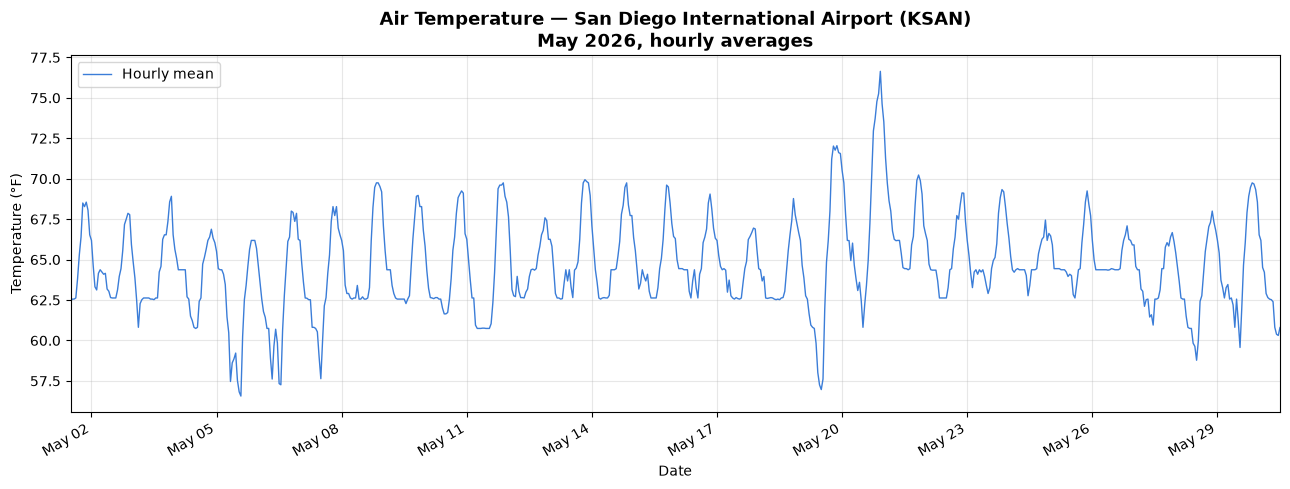

In [2]:
CSV = '/data/projects/WWRF-NRT/30YEAR-REFORECAST/MODE_verification/sshamsian/Forecast_verification_sshamsian/KSAN.2026-05-30.csv'
df = pd.read_csv(
    CSV,
    comment="#",            # drop the metadata block at the top
    skiprows=[11],          # drop the units row
    parse_dates=["Date_Time"],
)
 
df = df.rename(columns={"air_temp_set_1": "temp_F"})
df = df.dropna(subset=["Date_Time", "temp_F"])
df["temp_F"] = pd.to_numeric(df["temp_F"], errors="coerce")
df = df.dropna(subset=["temp_F"]).sort_values("Date_Time")
 
# Average the 5-minute readings into hourly means.
hourly = df.set_index("Date_Time")["temp_F"].resample("h").mean().dropna()
 
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(hourly.index, hourly.values, lw=1.0, color="#3b7dd8",
        label="Hourly mean")
 
ax.set_title("Air Temperature — San Diego International Airport (KSAN)\n"
             "May 2026, hourly averages",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (\u00b0F)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
ax.set_xlim(hourly.index.min(), hourly.index.max())
 
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate()
 
fig.tight_layout()
 
print(f"5-min rows: {len(df)}  ->  hourly points: {len(hourly)}")
print(f"Min/Mean/Max hourly temp (F): {hourly.min():.1f} / "
      f"{hourly.mean():.1f} / {hourly.max():.1f}")
 

## Plotting an object 1998 February 1st 24 hour lead time from the output generated by MODE 

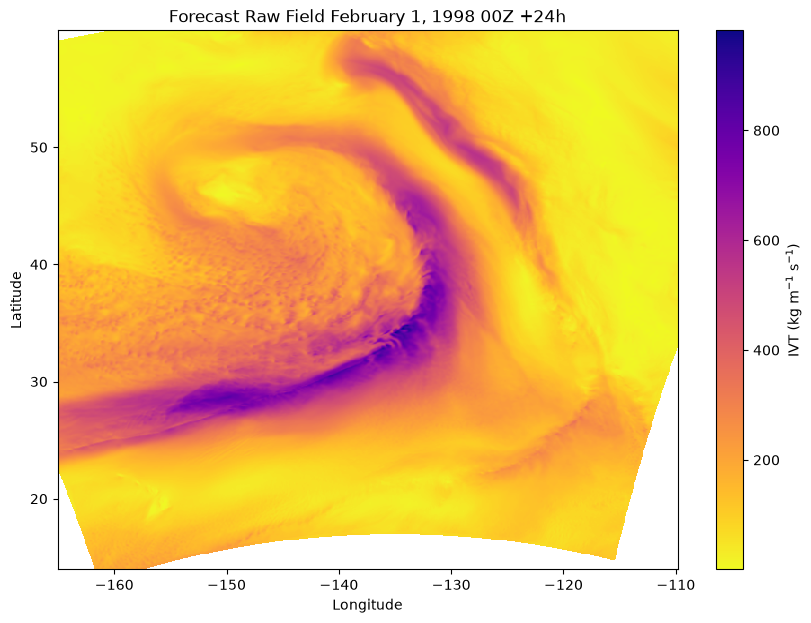

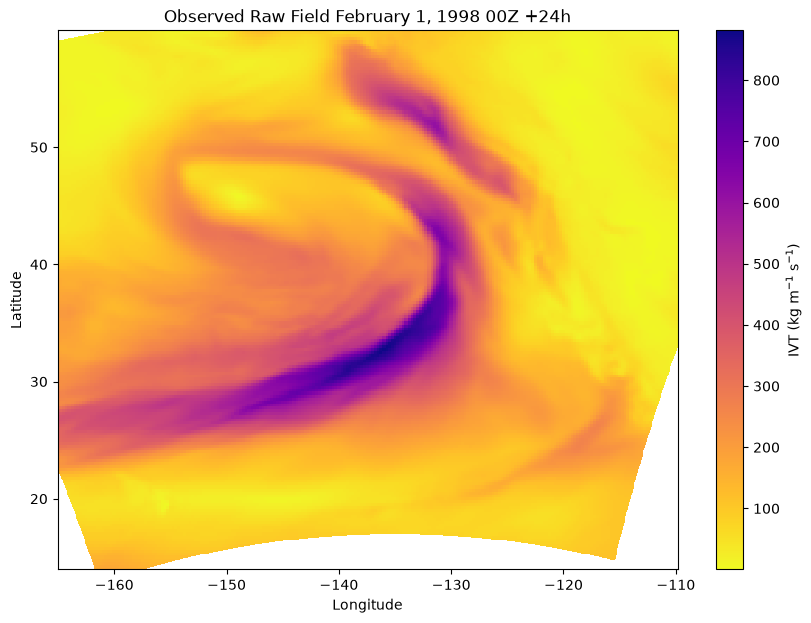

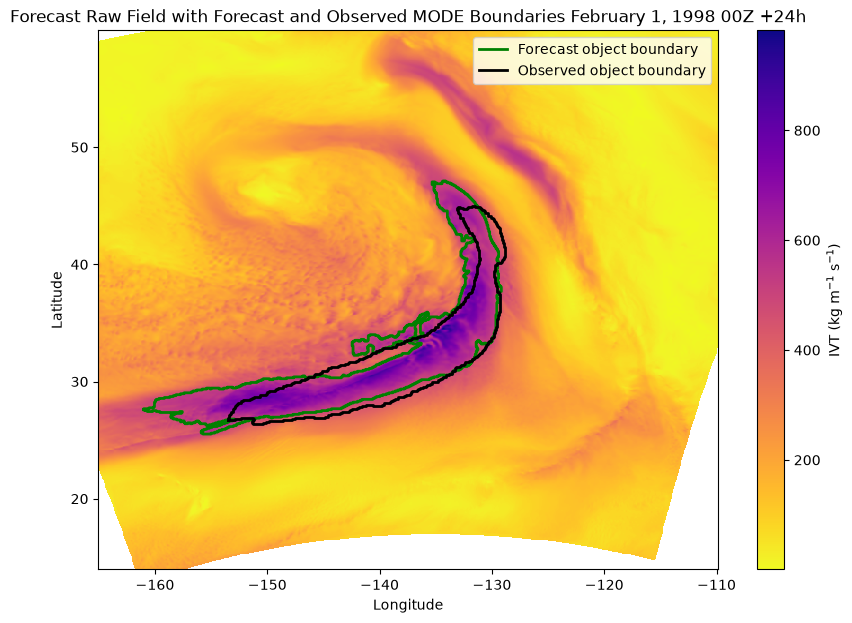

In [3]:
data_path = "/data/projects/WWRF-NRT/30YEAR-REFORECAST/MODE_verification/Raw_output/1998/1998020100/500/mode_WestWRF_240000L_19980201_000000V_000000A_obj.nc"
ds = xr.open_dataset(data_path)
plt.figure(figsize=(10, 7))
ds["fcst_raw"].plot(x="lon", y="lat", cmap="plasma_r", cbar_kwargs = {"label": "IVT (kg m$^{-1}$ s$^{-1}$)"})
plt.title("Forecast Raw Field February 1, 1998 00Z +24h")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

plt.figure(figsize=(10, 7))
ds["obs_raw"].plot(x="lon", y="lat", cmap="plasma_r", cbar_kwargs = {"label": "IVT (kg m$^{-1}$ s$^{-1}$)"})
plt.title("Observed Raw Field February 1, 1998 00Z +24h")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

plt.figure(figsize=(10, 7))

ds["fcst_raw"].plot(x="lon", y="lat", cmap="plasma_r", cbar_kwargs = {"label": "IVT (kg m$^{-1}$ s$^{-1}$)"})

plt.plot(
    ds["fcst_simp_bdy_lon"],
    ds["fcst_simp_bdy_lat"],
    color="green",
    linewidth=2,
    label="Forecast object boundary"
)

plt.plot(
    ds["obs_simp_bdy_lon"],
    ds["obs_simp_bdy_lat"],
    color="black",
    linewidth=2,
    label="Observed object boundary"
)

plt.title("Forecast Raw Field with Forecast and Observed MODE Boundaries February 1, 1998 00Z +24h")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

## Inspecting the text files for the MODE output 

#### CTS text file 

In [4]:
txt_file = "/data/projects/WWRF-NRT/30YEAR-REFORECAST/MODE_verification/Raw_output/1998/1998020100/500/mode_WestWRF_240000L_19980201_000000V_000000A_cts.txt"
# read in the text file as a DataFrame 
df = pd.read_csv(txt_file, sep=r"\s+", engine="python", header=0)

#2.) Clean up the column names and string values in the DataFrame.
df.columns = df.columns.str.strip().str.replace(r"\s+", "_", regex=True).str.lower()
for c in df.select_dtypes(include ="object").columns:
    df[c] = df[c].str.strip()

# 3) Convert statistic columns to numeric (remove leading >= or <= if present)
stat_cols = [
    "total","fy_oy","fy_on","fn_oy","fn_on","baser","fmean","acc","fbias",
    "pody","podn","pofd","far","csi","gss","hk","hss","odds","lodds","orss",
    "eds","seds","edi","sedi","bagss"
]
for c in stat_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(r"[<>]=?", "", regex=True), errors="coerce")

# 4) Optional: drop completely-empty cols / rows missing key fields
df = df.dropna(axis=1, how="all")
# example: require 'total' and 'acc' to be present
df = df.dropna(axis=0, subset=[col for col in ("total","acc") if col in df.columns])

print("shape:", df.shape)
print(df.columns.tolist())
print(df.head())

shape: (2, 47)
['version', 'model', 'n_valid', 'grid_res', 'fcst_lead', 'fcst_valid', 'fcst_accum', 'obs_lead', 'obs_valid', 'obs_accum', 'fcst_rad', 'fcst_thr', 'obs_rad', 'obs_thr', 'fcst_var', 'fcst_units', 'fcst_lev', 'obs_var', 'obs_units', 'obs_lev', 'obtype', 'field', 'total', 'fy_oy', 'fy_on', 'fn_oy', 'fn_on', 'baser', 'fmean', 'acc', 'fbias', 'pody', 'podn', 'pofd', 'far', 'csi', 'gss', 'hk', 'hss', 'odds', 'lodds', 'orss', 'eds', 'seds', 'edi', 'sedi', 'bagss']
   version model  n_valid  grid_res  fcst_lead       fcst_valid  fcst_accum  \
0  V12.1.0   WRF   370881         9     240000  19980201_000000           0   
1  V12.1.0   WRF   370881         9     240000  19980201_000000           0   

   obs_lead        obs_valid  obs_accum  ...       hk      hss       odds  \
0         0  19980201_000000          0  ...  0.72798  0.65989  123.88994   
1         0  19980201_000000          0  ...  0.77873  0.69707  183.46319   

     lodds     orss      eds     seds      edi     se

/tmp/ipykernel_969966/3917445121.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include ="object").columns:


### Plotting CSI and POFD data from the textfile

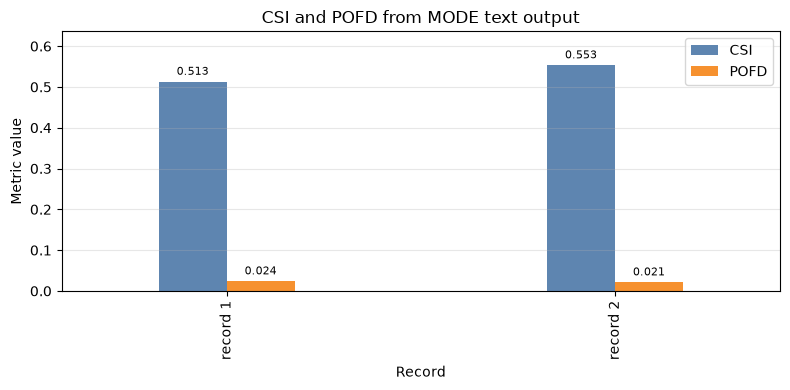

In [5]:

for c in df.columns[df.dtypes == "object"]:
    df[c] = df[c].str.strip()

for c in ["csi", "pofd"]:
    if c in df.columns:
        df[c] = pd.to_numeric(
            df[c].astype(str).str.replace(r"[<>]=?", "", regex=True),
            errors="coerce",
        )

plot_df = df[["csi", "pofd"]].dropna()

if plot_df.empty:
    raise ValueError("No CSI/POFD values were found in the text file.")

plot_df.index = [f"record {i + 1}" for i in range(len(plot_df))]

ax = plot_df.plot(
    kind="bar",
    figsize=(8, 4),
    color=["#4C78A8", "#F58518"],
    width=0.35,
    alpha=0.9,
)

ax.set_title("CSI and POFD from MODE text output")
ax.set_ylabel("Metric value")
ax.set_xlabel("Record")
ax.set_ylim(0, max(plot_df.max().max() * 1.15, 0.05))
ax.legend(["CSI", "POFD"])
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()


#### obj text file 

In [6]:
txt_file2 = "/data/projects/WWRF-NRT/30YEAR-REFORECAST/MODE_verification/Raw_output/1998/1998020100/500/mode_WestWRF_240000L_19980201_000000V_000000A_obj.txt"
# read in the text file as a DataFrame 
df2 = pd.read_csv(txt_file2, sep=r"\s+", engine="python", header=0)

# #2.) Clean up the column names and string values in the DataFrame.
# df2.columns = df2.columns.str.strip().str.replace(r"\s+", "_", regex=True).str.lower()
# for c in df2.select_dtypes(include ="object").columns:
#     df2[c] = df2[c].str.strip()

# # 3) Convert statistic columns to numeric (remove leading >= or <= if present)
# stat_cols = [
#     "total","fy_oy","fy_on","fn_oy","fn_on","baser","fmean","acc","fbias",
#     "pody","podn","pofd","far","csi","gss","hk","hss","odds","lodds","orss",
#     "eds","seds","edi","sedi","bagss"
# ]
# for c in stat_cols:
#     if c in df2.columns:
#         df2[c] = pd.to_numeric(df2[c].astype(str).str.replace(r"[<>]=?", "", regex=True), errors="coerce")

# # 4) Optional: drop completely-empty cols / rows missing key fields
# df2 = df2.dropna(axis=1, how="all")
# # example: require 'total' and 'acc' to be present
# df2 = df2.dropna(axis=0, subset=[col for col in ("total","acc") if col in df2.columns])

print("shape:", df2.shape)
print(df2.columns.tolist())
print(df2.head())

shape: (6, 58)
['VERSION', 'MODEL', 'N_VALID', 'GRID_RES', 'DESC', 'FCST_LEAD', 'FCST_VALID', 'FCST_ACCUM', 'OBS_LEAD', 'OBS_VALID', 'OBS_ACCUM', 'FCST_RAD', 'FCST_THR', 'OBS_RAD', 'OBS_THR', 'FCST_VAR', 'FCST_UNITS', 'FCST_LEV', 'OBS_VAR', 'OBS_UNITS', 'OBS_LEV', 'OBTYPE', 'OBJECT_ID', 'OBJECT_CAT', 'CENTROID_X', 'CENTROID_Y', 'CENTROID_LAT', 'CENTROID_LON', 'AXIS_ANG', 'LENGTH', 'WIDTH', 'AREA', 'AREA_THRESH', 'CURVATURE', 'CURVATURE_X', 'CURVATURE_Y', 'COMPLEXITY', 'INTENSITY_10', 'INTENSITY_25', 'INTENSITY_50', 'INTENSITY_75', 'INTENSITY_90', 'INTENSITY_50.1', 'INTENSITY_SUM', 'CENTROID_DIST', 'BOUNDARY_DIST', 'CONVEX_HULL_DIST', 'ANGLE_DIFF', 'ASPECT_DIFF', 'AREA_RATIO', 'INTERSECTION_AREA', 'UNION_AREA', 'SYMMETRIC_DIFF', 'INTERSECTION_OVER_AREA', 'CURVATURE_RATIO', 'COMPLEXITY_RATIO', 'PERCENTILE_INTENSITY_RATIO', 'INTEREST']
   VERSION MODEL  N_VALID  GRID_RES  DESC  FCST_LEAD       FCST_VALID  \
0  V12.1.0   WRF   370881         9   NaN     240000  19980201_000000   
1  V12.1.

## Secondary output csv file
- this csv file contains the necessary componenets that to caluclate MoE

In [8]:
sec_csv = "/data/projects/WWRF-NRT/30YEAR-REFORECAST/MODE_verification/Secondary_output/1998/1998020100/500/MODE_WestWRF_500_19980201_00.csv"
df_csv = pd.read_csv(sec_csv,sep='\s+', engine='python', header=0)
# 1) Parse valid_time into a real datetime
df_csv['valid_time'] = pd.to_datetime(df_csv['valid_time'], format='%Y%m%d_%H%M%S')

# 2) Convert lead_time from MET's HHMMSS-style int into plain hours
df_csv['lead_hours'] = (df_csv['lead_time'] // 10000).astype(int)
df_csv = df_csv.drop(columns=['lead_time'])

# 3) Round numeric columns to a sane number of decimals for readability
numeric_cols = ['centroid_lat', 'centroid_lon', 'intersect_area',
                 'fcst_90', 'obs_90', 'fcst_area', 'obs_area',
                 'fcst_angle', 'obs_angle']
df_csv[numeric_cols] = df_csv[numeric_cols].round(2)

# 4) Reorder columns so lead_hours and valid_time lead
cols_order = ['valid_time', 'lead_hours', 'centroid_lat', 'centroid_lon',
              'intersect_area', 'fcst_90', 'obs_90', 'fcst_area', 'obs_area',
              'fcst_angle', 'obs_angle']
df_csv = df_csv[cols_order]

# 5) Sort by lead time for a clean, ordered table
df_csv = df_csv.sort_values('lead_hours').reset_index(drop=True)

print(df_csv)

  valid_time  lead_hours  centroid_lat  centroid_lon  intersect_area  fcst_90  \
0 1998-02-01          24         32.63       -138.26           13555   750.22   
1 1998-02-01          48         32.63       -138.26           13740   804.24   
2 1998-02-01          72         32.63       -138.26           13666   942.66   
3 1998-02-01          96         32.63       -138.26           14643   846.64   
4 1998-02-01         120         32.63       -138.26            9926   905.18   
5 1998-02-01         144         32.63       -138.26            8950   873.67   
6 1998-02-01         168         32.63       -138.26           11720   978.51   

   obs_90  fcst_area  obs_area  fcst_angle  obs_angle  
0  789.33      21111     16942       27.79      32.43  
1  789.33      19059     16942       31.61      32.43  
2  789.33      21398     16942       31.47      32.43  
3  789.33      19575     16942       26.52      32.43  
4  789.33      16154     16942       28.93      32.43  
5  789.33      

<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_969966/2826526514.py:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df_csv = pd.read_csv(sec_csv,sep='\s+', engine='python', header=0)


### Computing MoE from sample date Feb 1st 1998 

In [9]:

def compute_moe(df):
    """Compute the Measure of Effectiveness (MoE) per DeHaan et al. 2021 (WAF).

    x_moe = intersect_area / obs_area   (false-negative measure)
    y_moe = intersect_area / fcst_area  (false-positive measure)

    Points on the y=x diagonal indicate forecast and observed objects
    are the same size (not necessarily same location).
    Above the diagonal: forecast object smaller than observed.
    Below the diagonal: forecast object larger than observed.
    """
    df = df.copy()
    df['x_moe'] = df['intersect_area'] / df['obs_area']
    df['y_moe'] = df['intersect_area'] / df['fcst_area']
    return df


df_csv = compute_moe(df_csv)
print(df_csv[['lead_hours', 'x_moe', 'y_moe']])

   lead_hours     x_moe     y_moe
0          24  0.800083  0.642082
1          48  0.811002  0.720919
2          72  0.806634  0.638658
3          96  0.864302  0.748046
4         120  0.585881  0.614461
5         144  0.528273  0.331740
6         168  0.691772  0.629532


##### Plotting MoE for Feb 1st 1998 

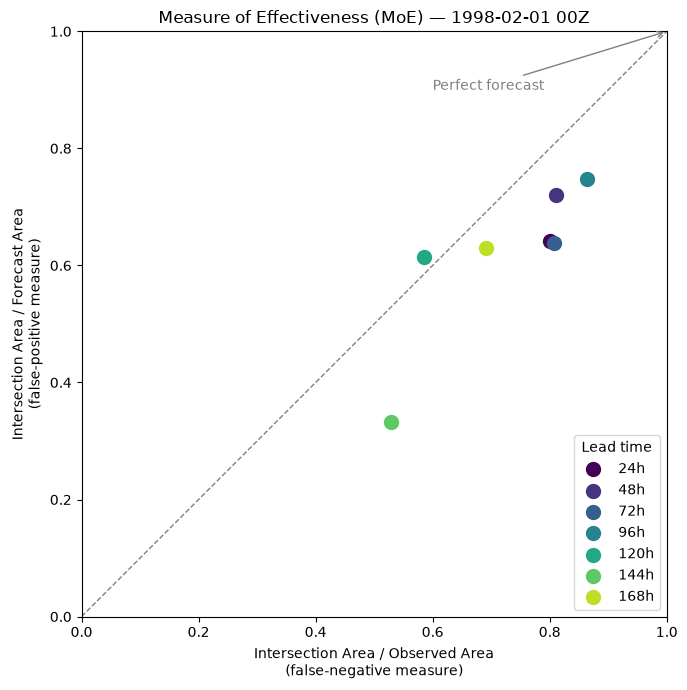

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

colors = plt.cm.viridis(np.linspace(0.0, 0.9, len(df_csv)))

for (_, row), color in zip(df_csv.iterrows(), colors):
    ax.scatter(row['x_moe'], row['y_moe'], color=color, s=100,
                label=f"{row['lead_hours']}h", zorder=3)

# 1:1 diagonal reference line
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, zorder=1)
ax.annotate("Perfect forecast", xy=(1,1), xytext=(0.6, 0.9), textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Intersection Area / Observed Area\n(false-negative measure)')
ax.set_ylabel('Intersection Area / Forecast Area\n(false-positive measure)')
ax.set_title('Measure of Effectiveness (MoE) — 1998-02-01 00Z')
ax.legend(title='Lead time', loc='lower right')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### Code for distance from perfect forecast 

In [12]:
def dist_perf(x_moe, y_moe, normalize=True):
    """Compute the distance from the perfect forecast point (1,1) in MoE space.

    Parameters
    ----------
    x_moe, y_moe : float or array-like
        MoE coordinates (intersect/obs and intersect/fcst ratios), each in [0, 1].
    normalize : bool
        If True, divide by sqrt(2) (max possible distance) so output is in [0, 1],
        where 0 = perfect forecast and 1 = complete miss.

    Returns
    -------
    float or array-like
        Distance from perfect forecast, in [0, sqrt(2)] or [0, 1] if normalized.
    """
    dist = np.sqrt((x_moe - 1)**2 + (y_moe - 1)**2)
    if normalize:
        dist = dist / np.sqrt(2)
    return dist


### Applying it to my dataframe

In [13]:
df_csv['dist_perf'] = dist_perf(df_csv['x_moe'], df_csv['y_moe'])
print(df_csv[['lead_hours', 'x_moe', 'y_moe', 'dist_perf']])

   lead_hours     x_moe     y_moe  dist_perf
0          24  0.800083  0.642082   0.289890
1          48  0.811002  0.720919   0.238334
2          72  0.806634  0.638658   0.289792
3          96  0.864302  0.748046   0.202355
4         120  0.585881  0.614461   0.400084
5         144  0.528273  0.331740   0.578402
6         168  0.691772  0.629532   0.340772


#### Plotting the distance from perfect forecast 

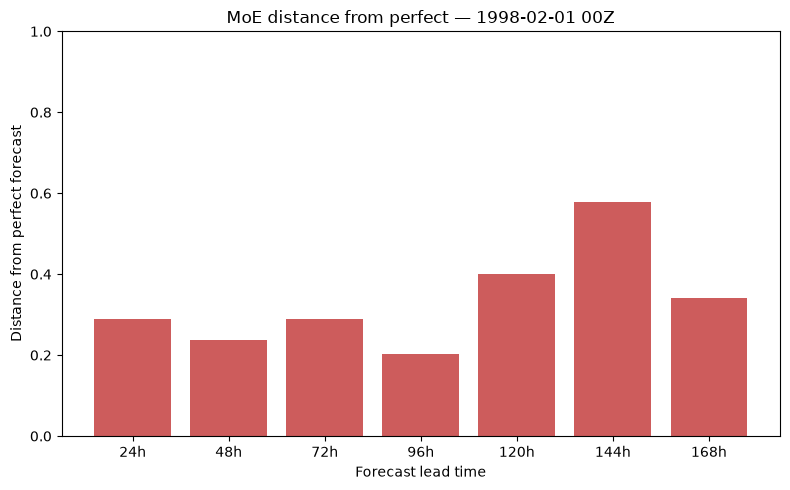

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(df_csv['lead_hours'].astype(str) + 'h', df_csv['dist_perf'], color='indianred')
plt.xlabel('Forecast lead time')
plt.ylabel('Distance from perfect forecast')
plt.title('MoE distance from perfect — 1998-02-01 00Z')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## AR lead times overlaid on one observed data plot on one plot 

In [ ]:

lead_hours = [24, 48, 72, 96, 120, 144, 168]

def parse_lead_hours(path):
    """Extract the forecast lead time in hours from a MODE filename.

    Parameters
    ----------
    path : str
        Path to a MODE netCDF file.

    Returns
    -------
    int or None
        Lead time in hours, or None if no match is found.
    """
    match = re.search(r'_(\d+)L_', os.path.basename(path))
    if match:
        return int(match.group(1)) // 10000
    return None
# globs the netcdf files in the directory and sorts them into a list of paths
nc_files = sorted(glob.glob(
    '/data/projects/WWRF-NRT/30YEAR-REFORECAST/MODE_verification/Raw_output/1998/1998020100/500/*.nc',
    recursive=True,
))

lead_files = []
for path in nc_files:
    lead = parse_lead_hours(path)
    if lead in lead_hours:
        lead_files.append((lead, path))
lead_files.sort(key=lambda item: item[0])


Found lead times: [24, 48, 72, 96, 120, 144, 168]


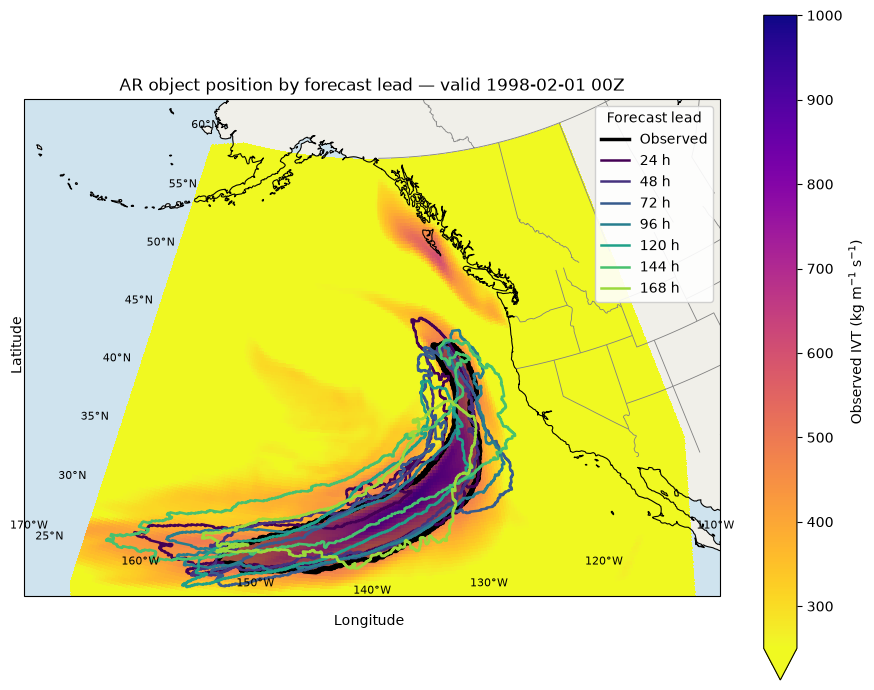

In [ ]:


lead_hours = [24, 48, 72, 96, 120, 144, 168] # list contianing the lead hours for the ARs 
ivt_level  = 500          # MODE convolution threshold (only used for the field background)
SHOW_FIELD = True         # True = viridis obs IVT field behind the objects, like your figure

# --- helpers functions ----------------
def _bdy_vars(ds, prefix):
    """Resolve the boundary index variable names for a MODE object dataset.

    Parameters
    ----------
    ds : xarray.Dataset
        Opened MODE netCDF dataset.
    prefix : str
        Variable prefix for forecast or observed fields, such as "fcst" or "obs".

    Returns
    -------
    tuple of str
        Names of the start-index and point-count variables for the simplified boundary.

    Raises
    ------
    KeyError
        If the expected boundary variables are not present in the dataset.
    """

    start = f"{prefix}_simp_bdy_start"
    npts  = next((f"{prefix}_simp_bdy_{s}" for s in ("npts", "lens", "count")
                  if f"{prefix}_simp_bdy_{s}" in ds), None)
    if start not in ds or npts is None:
        raise KeyError(f"Couldn't find {prefix} boundary index vars. Available: "
                       f"{[v for v in ds.variables if 'simp_bdy' in v]}")
    return start, npts

def iter_objects(ds, prefix):
    """Yield closed polygon coordinates for each simplified MODE object.

    Parameters
    ----------
    ds : xarray.Dataset
        Opened MODE netCDF dataset.
    prefix : str
        Variable prefix for forecast or observed fields, such as "fcst" or "obs".

    Yields
    ------
    tuple of numpy.ndarray
        Longitude and latitude arrays for one closed object boundary.
    """
    lon = np.asarray(ds[f"{prefix}_simp_bdy_lon"])
    lat = np.asarray(ds[f"{prefix}_simp_bdy_lat"])
    s_name, n_name = _bdy_vars(ds, prefix)
    start = np.asarray(ds[s_name]).astype(int)
    npts  = np.asarray(ds[n_name]).astype(int)
    for s, n in zip(start, npts): # loops through the objects one at a time
        xs, ys = lon[s:s+n], lat[s:s+n]
        yield np.append(xs, xs[0]), np.append(ys, ys[0]) # the yield hands back that objects closed [lat,lon] polygon. The yield makes this functions as a generator, instead of building a list of all objects up front 

# --------------------------------------------------------------------------
# This walks over my nc_files list and keeps only the ones whose parsed lead is in by original list in the previous code cell 
# and then it pairs each path with its lead as (lead, path).sorted then order them by lead ascending (basically tuples sort by their first element), so that the plot and legend come out 24-68 in order 
lead_files = sorted(
    (parse_lead_hours(p), p) for p in nc_files
    if parse_lead_hours(p) in lead_hours
)
# this is just in case the lead_files have nothing in them and are completely empty basically just a safe guard 
if not lead_files:
    print('No forecast files found for lead times 24-168 h. '
          'Update the path or extract the .nc files first.')
else:
    print('Found lead times:', [lead for lead, _ in lead_files])
    proj = ccrs.LambertConformal(
        central_longitude=-140,
        central_latitude=45,
        standard_parallels=(30, 60))
    
    fig, ax = plt.subplots(figsize=(9, 7),subplot_kw={'projection': proj})
    # Set the map extent to cover the AK -> CA West Coast domain
    # [lon_min, lon_max, lat_min, lat_max]
    ax.set_extent([-170, -110, 25, 62], crs=ccrs.PlateCarree())

    # --- background features ---
    ax.add_feature(cfeature.OCEAN, facecolor='#cfe3ee', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='#f0efe9', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)

    # State boundaries (includes Alaska + California)
    states = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none'
    )
    ax.add_feature(states, edgecolor='gray', linewidth = 0.6, zorder=1)


    # Observed: same valid time across all leads -> load once, draw once.
    # this basically open the first file in the lead_files list and then it extracts the observed field from that file and then it plots it as a background field behind the forecast objects
    ds0 = xr.open_dataset(lead_files[0][1])
    obs = ds0['obs_raw']

    if SHOW_FIELD:                              # plasma IVT field behind everything
        obs.plot(ax=ax, x='lon', y='lat', cmap='plasma_r', zorder=0,transform = ccrs.PlateCarree(),
                 cbar_kwargs={'label': 'Observed IVT (kg m$^{-1}$ s$^{-1}$)'}, vmin = 250, vmax = 1000)
    # this basically open the first file in the lead_files list and then it extracts the observed field from that file and then it plots it as a background field behind the forecast objects    plt.show()


    ds0 = xr.open_dataset(lead_files[0][1])    
    plt.tight_layout()

    for xs, ys in iter_objects(ds0, 'obs'):    # shade + outline the observed object and loop through the observed objects 
        ax.fill(xs, ys, facecolor='black', alpha=0.30, zorder=3,transform = ccrs.PlateCarree()) # alpha =0.3 makes it 30 percent opaque so the IVT field still shows through
        ax.plot(xs, ys, color='black', lw=3.5, zorder=4, transform=ccrs.PlateCarree()) # ax.plot draw the solid black outline on top, and the z order numbers what is drawn first and on top of what.

    # Forecast: one boundary per lead, colored by lead time.
    colors  = plt.cm.viridis(np.linspace(0.0, 0.85, len(lead_files))) # samples N evenly spaced colors along the plasma colored map one per lead, stopping at 0.85 to avoid the pale yellow tail 
    handles = [Line2D([0], [0], color='black', lw=2.5, label='Observed')] # this is just a manual legend Each forecast lead draws potentially several line segments, and letting matplotlib auto-build the legend from those would give me a cluttered, repeated mess.
    # 
    for (lead, path), color in zip(lead_files, colors):
        ds = xr.open_dataset(path)
        if 'fcst_simp_bdy_lon' not in ds:
            continue
        for i, (xs, ys) in enumerate(iter_objects(ds, 'fcst')):
            ax.plot(xs, ys, color=color, lw=1.8, zorder=5, transform=ccrs.PlateCarree())
        handles.append(Line2D([0], [0], color=color, lw=1.8, label=f'{lead} h'))

    ax.legend(handles=handles, title='Forecast lead', loc='upper right', framealpha=0.9)
    ax.set_title('AR object position by forecast lead — valid 1998-02-01 00Z')
    # ax.set_xlabel('Longitude')
    # ax.set_ylabel('Latitude')
    fig.text(0.4, 0.1, 'Longitude', ha='center', fontsize=10)
    fig.text(0.001, 0.5, 'Latitude', va='center', rotation='vertical', fontsize=10)
     # --- FIXED: labels moved inside the extent + zorder added so they draw on top ---
    for lon in [-170, -160, -150, -140, -130, -120, -110]:
        ax.text(lon, 26, f'{abs(lon)}°W', transform=ccrs.PlateCarree(),
                 ha='center', va='top', fontsize=8, zorder=10)

    for lat in [25, 30, 35, 40, 45, 50, 55, 60]:
        ax.text(-169, lat, f'{lat}°N', transform=ccrs.PlateCarree(),
                 ha='left', va='center', fontsize=8, zorder=10)
    # --- END FIX ---
    #plt.tight_layout()
    plt.show()